## 1. Transformaciones 2D y matrices afines

La **pose de un robot** en el plano, respecto a un sistema de coordenadas global, se puede expresar como:

$\mathbf{x} = (x,\,y,\,\theta)^T$

donde $(x,\,y)^T$ es la posición y $\theta$ la orientación.

La **matriz de transformación homogénea** asociada a esta pose se puede escribir:

$$
T =
\begin{pmatrix}
R(\theta) & \mathbf{t} \\
0 ~~ & 1
\end{pmatrix}
$$

donde $ R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & ~~\cos\theta \end{pmatrix} $ y $\mathbf{t} = \begin{pmatrix} x \\ y \end{pmatrix}$

---

**1.** Si el robot está en la pose $\mathbf{x}_1 = (x_1, y_1, \theta_1)^T$ y detecta un obstáculo $p$ en la posición $(p_x, p_y)$ respecto a *su propia* referencia, usando la matriz $T_1$ podemos expresar las coordenadas del obstáculo en la terna global como:

$$
\mathbf{p}_g = T_1 \, \mathbf{p}_{x_1}
$$

Es decir, $T_1$ es la transformación que lleva las coordenadas del robot al sistema global.

---

**2.** Si conocemos las coordenadas de un obstáculo en el sistema global, ¿cómo las expresamos en la terna del robot?

$$
\mathbf{p}_{x_1} = T_1^{-1} \, \mathbf{p}_g
$$

De la misma manera que $T_1$ nos lleva de la terna del robot al mundo, su inversa nos lleva de mundo al robot.  
Esta matriz es invertible porque $T_1$ está construida a partir de una matriz de rotación (que por definición es invertible y tiene determinante 1) y una traslación. La estructura garantiza que siempre existe la inversa, y se puede verificar que:

- La submatriz de rotación $R(\theta_1)$ tiene determinante 1.
- El bloque inferior es simplemente un vector de ceros y un 1, así que la inversa se mantiene simple.

---

**3.** Supongamos que el robot se mueve a una nueva pose $\mathbf{x}_2 = (x_2, y_2, \theta_2)^T$.  
La matriz de transformación que lleva la nueva terna local (del robot) respecto a la anterior se calcula como:

$$
T_{12} = T_1^{-1} \, T_2
$$

¿De dónde sale esto?  
Buscamos una transformación que pase de la primera referencia del robot a la segunda.  
Sabemos que:

- $T_1$ transforma de la terna del robot 1 al mundo.
- $T_2$ transforma de la terna del robot 2 al mundo.

Así, para ir de la terna 1 a la 2, primero vamos de 1 a global ($T_1$), luego de global a 2 (usando $T_2^{-1}$), o al revés, según el sentido.

Sin embargo, queriendo expresar todo respecto al sistema global, la relación correcta es:

$$
T_1 \cdot T_{12} = T_2 \implies T_{12} = T_1^{-1} T_2
$$

De aquí descontamos la contribución de la pose 1 en el mundo y sumamos la contribución de la pose 2.

---

**4.** Ahora, estando el robot en la posición $\mathbf{x}_2$, ¿dónde estará el obstáculo $p$ respecto a la nueva terna local?

$$
\mathbf{p}_{x_2} = T_{12}\, \mathbf{p}_{x_1} = T_2 \, \mathbf{p}_g
$$

En otras palabras, la posición del obstáculo respecto de la terna 2 se puede calcular en dos formas equivalentes:

1. Transformando la posición que tenía respecto de la terna 1 usando $T_{12}$.
2. Usando directamente la transformación homogénea $T_2$ sobre la posición global del obstáculo.

Esto cierra el ciclo de las transformaciones homogéneas en el plano, y su utilidad para transformar posiciones y puntos entre distintas referencias.

# Parte 2 - Sensado

Ejercicio 1: Graficar las mediciones en la terna de referencia del LIDAR


/home/elianaostro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


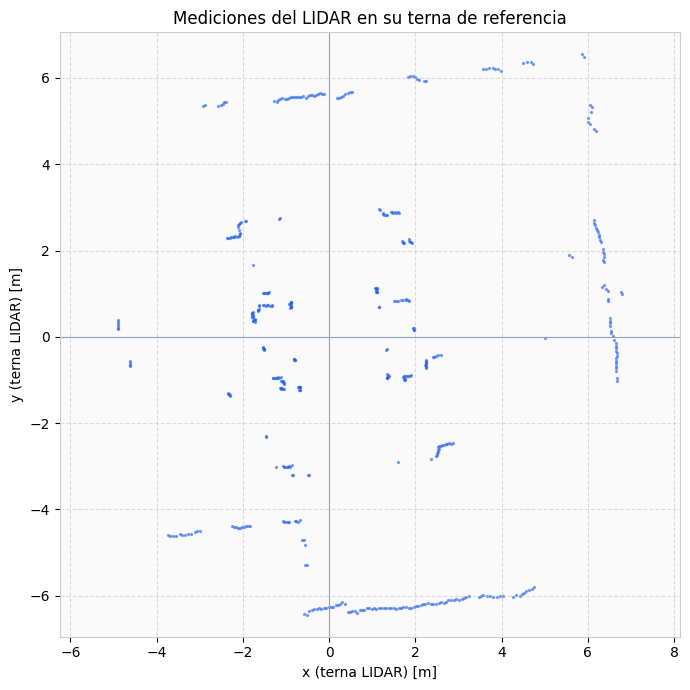

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Estilo simple y limpio para todos los gráficos
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.size'] = 10

with open('scan.pkl', 'rb') as f:
    scan = pickle.load(f)

angle_min = scan['angle_min']
angle_max = scan['angle_max']
angle_increment = scan['angle_increment']
range_min = scan['range_min']
range_max = scan['range_max']
ranges = np.array(scan['ranges'])
intensities = np.array(scan['intensities'])

valid = (ranges >= range_min) & (ranges <= range_max) & (intensities > 0)
ranges_filt = ranges[valid]

n = len(ranges)
angles = angle_min + np.arange(n) * angle_increment
angles_filt = angles[valid]

# Coordenadas en la terna del LIDAR (2D):
# x = r * cos(angle), y = r * sin(angle)
x_lidar = ranges_filt * np.cos(angles_filt)
y_lidar = ranges_filt * np.sin(angles_filt)

plt.figure(figsize=(7, 7))
plt.scatter(x_lidar, y_lidar, s=2, c='#2563eb', alpha=0.5)
plt.axhline(0, color='#94a3b8', linewidth=0.8)
plt.axvline(0, color='#94a3b8', linewidth=0.8)
plt.xlabel('x (terna LIDAR) [m]')
plt.ylabel('y (terna LIDAR) [m]')
plt.title('Mediciones del LIDAR en su terna de referencia')
plt.axis('equal')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Ejercicio 2: Interpretacion del entorno a partir de las mediciones

Analizando la gráfica del LIDAR, parece que el robot se encuentra dentro de una habitación cuadrada, de unos 10 por 10 metros. Se observa un obstáculo grande junto a la pared en la esquina inferior izquierda y varios objetos más pequeños cerca del robot, indicando que el entorno es cerrado y presenta obstáculos tanto en los bordes como en los alrededores inmediatos del robot.

Ejercicio 3: Transformaciones homogéneas - robot, LIDAR y mediciones en terna global

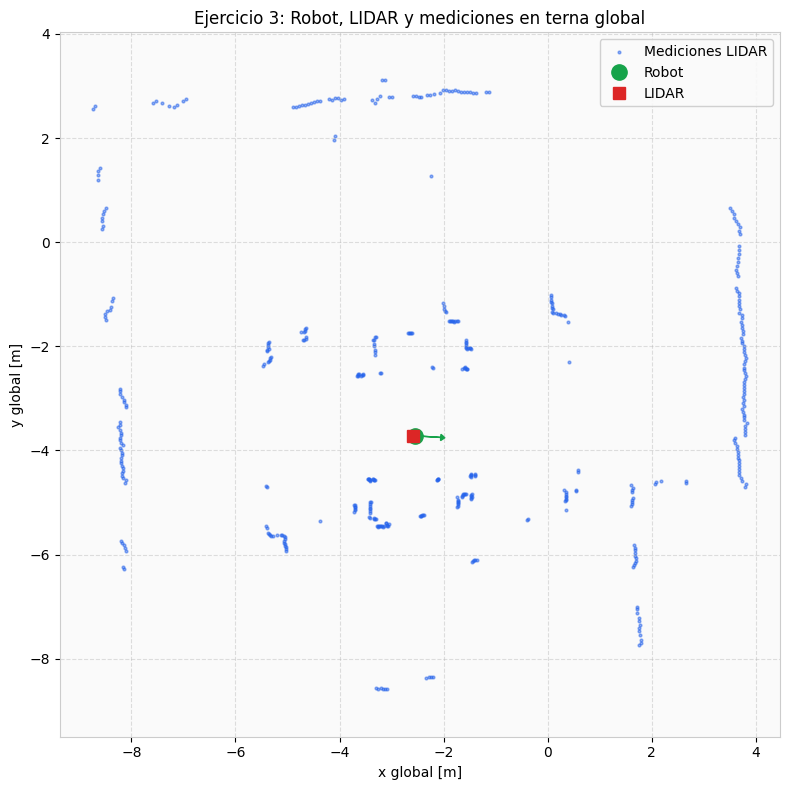

In [2]:
import pandas as pd

odom = pd.read_csv('odom.csv')
pos_x = odom['pos_x'].values[0]
pos_y = odom['pos_y'].values[0]
qx = odom['quat_x'].values[0]
qy = odom['quat_y'].values[0]
qz = odom['quat_z'].values[0]
qw = odom['quat_w'].values[0]

yaw = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

def T_rigid_2d(x, y, theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, x],
        [s,  c, y],
        [0,  0, 1]
    ])

T_global_robot = T_rigid_2d(pos_x, pos_y, yaw)

robot_T_lidar_3x3 = np.array([
    [ 0.00, -1.00, -0.04],
    [ 1.00,  0.00,  0.00],
    [ 0.00,  0.00,  1.00]
])

T_global_lidar = T_global_robot @ robot_T_lidar_3x3

ones = np.ones_like(x_lidar)
p_lidar = np.vstack([x_lidar, y_lidar, ones]) 

p_global = T_global_lidar @ p_lidar
x_global = p_global[0, :]
y_global = p_global[1, :]

origen_lidar_global = T_global_lidar @ np.array([[0], [0], [1]])
lidar_x_global = origen_lidar_global[0, 0]
lidar_y_global = origen_lidar_global[1, 0]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(x_global, y_global, s=4, c='#2563eb', alpha=0.5, label='Mediciones LIDAR')
ax.plot(pos_x, pos_y, 'o', color='#16a34a', markersize=11, label='Robot')
ax.arrow(pos_x, pos_y, 0.5*np.cos(yaw), 0.5*np.sin(yaw), head_width=0.12, head_length=0.08, fc='#16a34a', ec='#16a34a')
ax.plot(lidar_x_global, lidar_y_global, 's', color='#dc2626', markersize=9, label='LIDAR')
ax.set_xlabel('x global [m]')
ax.set_ylabel('y global [m]')
ax.set_title('Ejercicio 3: Robot, LIDAR y mediciones en terna global')
ax.axis('equal')
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Parte 3 - Accionamiento diferencial

Ejercicio 1: Función de cinemática directa

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def diffdrive(x, y, theta, v_l, v_r, t, l):
    """
    Cinemática directa de un robot diferencial.
    x, y, theta: pose actual
    v_l, v_r: velocidades de rueda izquierda y derecha
    t: intervalo de tiempo
    l: distancia entre ruedas
    Retorna: x_n, y_n, theta_n (nueva pose)
    """
    if np.isclose(v_l, v_r):
        # Movimiento recto
        x_n = x + v_l * t * np.cos(theta)
        y_n = y + v_l * t * np.sin(theta)
        theta_n = theta
    else:
        # Movimiento curvo
        R = (l / 2) * (v_r + v_l) / (v_r - v_l)
        omega = (v_r - v_l) / l
        # Centro instantáneo de curvatura (ICC)
        icc_x = x - R * np.sin(theta)
        icc_y = y + R * np.cos(theta)
        dtheta = omega * t
        x_n = np.cos(dtheta) * (x - icc_x) - np.sin(dtheta) * (y - icc_y) + icc_x
        y_n = np.sin(dtheta) * (x - icc_x) + np.cos(dtheta) * (y - icc_y) + icc_y
        theta_n = theta + dtheta
    return x_n, y_n, theta_n

Ejercicio 2: Secuencia de acciones y gráfico del movimiento

Pose final: x=0.3023 m, y=0.1162 m, theta=-8.8146 rad (-505.04°)


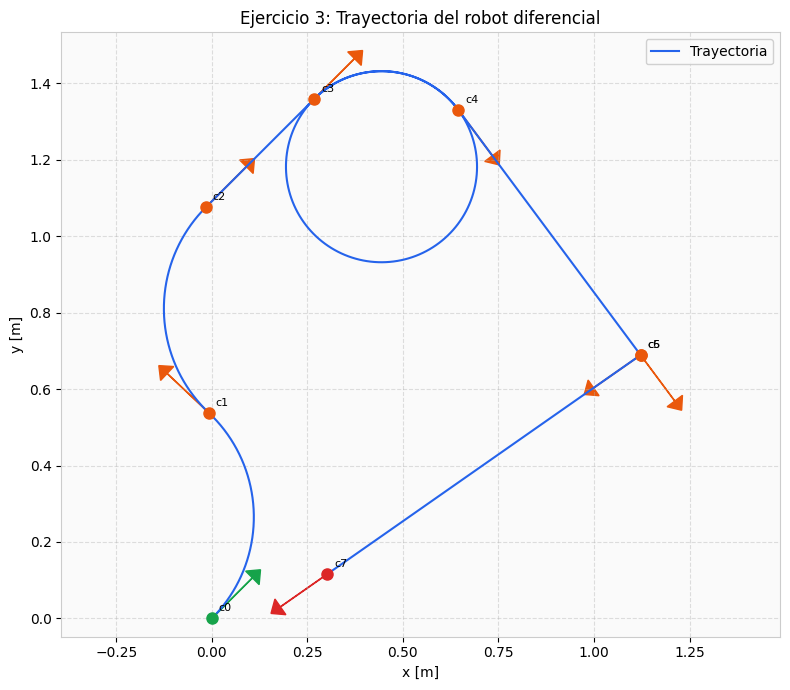

In [4]:
x, y, theta = 0.0, 0.0, np.pi / 4
l = 0.5 

commands = [
    (0.1, 0.5, 2),
    (0.5, 0.1, 2),
    (0.2, 0.2, 2),
    (1.0, 0.0, 4),
    (0.4, 0.4, 2),
    (0.2, -0.2, 2),
    (0.5, 0.5, 2),
]

dt = 0.01 
traj_x, traj_y = [x], [y]
poses = [(x, y, theta)]

for v_l, v_r, t_cmd in commands:
    steps = int(t_cmd / dt)
    for _ in range(steps):
        x, y, theta = diffdrive(x, y, theta, v_l, v_r, dt, l)
        traj_x.append(x)
        traj_y.append(y)
    poses.append((x, y, theta))

print(f"Pose final: x={x:.4f} m, y={y:.4f} m, theta={theta:.4f} rad ({np.degrees(theta):.2f}°)")

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(traj_x, traj_y, color='#2563eb', linewidth=1.5, label='Trayectoria')

for i, (px, py, pt) in enumerate(poses):
    color = '#16a34a' if i == 0 else ('#dc2626' if i == len(poses)-1 else '#ea580c')
    ax.plot(px, py, 'o', color=color, markersize=8)
    ax.arrow(px, py, 0.15*np.cos(pt), 0.15*np.sin(pt),
             head_width=0.05, head_length=0.03, fc=color, ec=color)
    ax.annotate(f'c{i}', (px, py), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Ejercicio 3: Trayectoria del robot diferencial')
ax.axis('equal')
ax.grid(True, linestyle='--')
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()